# Notebook 02 · Statistical Behavior Analysis

## Objetivo

Analizar el comportamiento estadístico de las principales variables del modelo para comprender su distribución, identificar patrones y preparar la fase de Feature Engineering.

## 1. Importación de librerías y configuración inicial

In [2]:
# =============================================================================
# IMPORTACIÓN DE LIBRERÍAS
# =============================================================================

import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
# =============================================================================
# CONFIGURACIÓN INICIAL
# =============================================================================

# Mostrar todas las columnas de los DataFrames
pd.set_option('display.max_columns', None)

# Mostrar números con dos decimales
pd.options.display.float_format = '{:.2f}'.format


## 2. Conexión con la base de datos

In [4]:
# =============================================================================
# CONFIGURACIÓN DEL ENTORNO
# =============================================================================

# Ruta raíz del proyecto
PROJECT_ROOT = Path.cwd().parent

# Ruta de la base de datos SQLite
DATABASE_PATH = PROJECT_ROOT / "data" / "raw" / "database" / "bank_sqlite.db"

# Conexión a la base de datos
try:
    connection = sqlite3.connect(DATABASE_PATH)
    print("✅ Conexión con la base de datos establecida correctamente.")
except sqlite3.Error as error:
    print(f"❌ Error al conectar con la base de datos: {error}")
    raise

✅ Conexión con la base de datos establecida correctamente.


## 3. Construcción del dataset analítico

In [5]:
# =============================================================================
# ACCOUNTS_SUMMARY
# =============================================================================
# Resumen de cuentas por cliente
# =============================================================================

query_accounts_summary = """
SELECT
    customer_id,
    COUNT(account_id) AS total_accounts,
    SUM(balance_usd) AS total_balance
FROM accounts
GROUP BY customer_id;
"""

accounts_summary = pd.read_sql(
    sql=query_accounts_summary,
    con=connection
)

accounts_summary.head()

,customer_id,total_accounts,total_balance
0,CUS000MKX5RHTAP,1,151677.32
1,CUS002V4AVJO5UQ,1,178960.28
2,CUS004THQ8NDQW3,1,131026.41
3,CUS007GCM2J726A,2,81689.89
4,CUS00AO13A3Q5FO,2,189090.18


## 4. Validación del dataset

In [6]:
# =============================================================================
# VALIDACIÓN DE ACCOUNTS_SUMMARY
# =============================================================================

print(f"Filas: {accounts_summary.shape[0]}")
print(f"Columnas: {accounts_summary.shape[1]}")

display(accounts_summary.head())

accounts_summary.describe().T

Filas: 38849
Columnas: 3


,customer_id,total_accounts,total_balance
0,CUS000MKX5RHTAP,1,151677.32
1,CUS002V4AVJO5UQ,1,178960.28
2,CUS004THQ8NDQW3,1,131026.41
3,CUS007GCM2J726A,2,81689.89
4,CUS00AO13A3Q5FO,2,189090.18


,count,mean,std,min,25%,50%,75%,max
total_accounts,38849.00,1.93,1.05,1.00,1.00,2.00,2.00,9.00
total_balance,38849.00,192904.29,133145.84,13.67,95174.34,168426.01,267595.27,1040545.37


### Validación

- Se han obtenido 38.849 clientes con al menos una cuenta.
- La granularidad es una fila por cliente.
- Las variables agregadas presentan valores coherentes.

In [7]:
# =============================================================================
# CARDS_SUMMARY
# =============================================================================
# Resumen de tarjetas por cliente
# =============================================================================

query_cards_summary = """
SELECT
    a.customer_id,
    COUNT(c.card_id) AS total_cards
FROM accounts AS a
INNER JOIN cards AS c
    ON a.account_id = c.account_id
GROUP BY a.customer_id;
"""

cards_summary = pd.read_sql(
    sql=query_cards_summary,
    con=connection
)

cards_summary.head()

,customer_id,total_cards
0,CUS000MKX5RHTAP,4
1,CUS002V4AVJO5UQ,1
2,CUS004THQ8NDQW3,1
3,CUS007GCM2J726A,2
4,CUS00AO13A3Q5FO,1


In [8]:
# =============================================================================
# VALIDACIÓN DE CARDS_SUMMARY
# =============================================================================

print(f"Filas: {cards_summary.shape[0]}")
print(f"Columnas: {cards_summary.shape[1]}")

display(cards_summary.head())

cards_summary.describe().T

Filas: 33485
Columnas: 2


,customer_id,total_cards
0,CUS000MKX5RHTAP,4
1,CUS002V4AVJO5UQ,1
2,CUS004THQ8NDQW3,1
3,CUS007GCM2J726A,2
4,CUS00AO13A3Q5FO,1


,count,mean,std,min,25%,50%,75%,max
total_cards,33485.00,2.99,2.01,1.00,1.00,2.00,4.00,17.00


### Validación

- Se han obtenido 33.485 clientes con al menos una tarjeta.
- La granularidad es una fila por cliente.
- Las variables agregadas presentan valores coherentes.

In [9]:
# =============================================================================
# LOANS_SUMMARY
# =============================================================================
# Resumen de préstamos por cliente
# =============================================================================

query_loans_summary = """
SELECT
    customer_id,
    COUNT(l.loan_id) AS total_loans,
    SUM(l.loan_amount) AS total_loan_amount
FROM loans AS l
GROUP BY customer_id;
"""

loans_summary = pd.read_sql(
    sql=query_loans_summary,
    con=connection
)

loans_summary.head()

,customer_id,total_loans,total_loan_amount
0,CUS004THQ8NDQW3,1,204044.40
1,CUS00AO13A3Q5FO,1,61678.80
2,CUS00B3PZUTUEKH,1,70588.67
3,CUS00BGBB1R3YQS,1,154258.16
4,CUS00EZ13D39OC4,1,259543.08


In [10]:
# =============================================================================
# VALIDACIÓN DE LOANS_SUMMARY
# =============================================================================

print(f"Filas: {loans_summary.shape[0]}")
print(f"Columnas: {loans_summary.shape[1]}")

loans_summary.describe().T

Filas: 22540
Columnas: 3


,count,mean,std,min,25%,50%,75%,max
total_loans,22540.00,1.33,0.60,1.00,1.00,1.00,2.00,5.00
total_loan_amount,22540.00,200226.26,133898.92,1023.76,97974.57,187952.57,270688.70,1162259.84


### Validación

- Se han obtenido 22.540 clientes con al menos un préstamo.
- La granularidad es una fila por cliente.
- Las variables agregadas presentan valores coherentes.

In [11]:
# =============================================================================
# TRANSACTIONS_SUMMARY
# =============================================================================
# Resumen de transacciones por cliente
# =============================================================================

query_transactions_summary = """
SELECT
    a.customer_id,
    COUNT(t.transaction_id) AS total_transactions,
    SUM(t.amount_usd) AS total_transaction_amount
FROM accounts AS a
INNER JOIN transactions AS t
    ON a.account_id = t.account_id
GROUP BY a.customer_id;
"""

transactions_summary = pd.read_sql(
    sql=query_transactions_summary,
    con=connection
)

transactions_summary.head()

,customer_id,total_transactions,total_transaction_amount
0,CUS000MKX5RHTAP,6,26890.44
1,CUS002V4AVJO5UQ,16,76937.17
2,CUS004THQ8NDQW3,9,33025.48
3,CUS007GCM2J726A,20,107590.15
4,CUS00AO13A3Q5FO,26,120446.58


In [12]:
# =============================================================================
# VALIDACIÓN DE TRANSACTIONS_SUMMARY
# =============================================================================

print(f"Filas: {transactions_summary.shape[0]}")
print(f"Columnas: {transactions_summary.shape[1]}")

transactions_summary.describe().T

Filas: 38849
Columnas: 3


,count,mean,std,min,25%,50%,75%,max
total_transactions,38849.00,25.74,14.94,2.00,14.00,23.00,34.00,122.00
total_transaction_amount,38849.00,128733.42,76337.31,2579.63,68862.97,111343.26,169614.75,655536.37


### Validación

- Se han obtenido 38.849 clientes con al menos una transacción.
- La granularidad es una fila por cliente.
- Las variables agregadas presentan valores coherentes.

In [13]:
query = """
PRAGMA table_info(customers);
"""

pd.read_sql(query, connection)

,cid,name,type,notnull,dflt_value,pk
0,0,customer_id,TEXT,0,None,0
1,1,first_name,TEXT,0,None,0
2,2,last_name,TEXT,0,None,0
3,3,email,TEXT,0,None,0
4,4,city,TEXT,0,None,0
5,5,credit_score,INTEGER,0,None,0
6,6,created_at,TIMESTAMP,0,None,0


In [14]:
# =============================================================================
# CUSTOMER_ANALYSIS_DATASET
# =============================================================================
# Construcción del dataset analítico a nivel de cliente
# =============================================================================

query_customer_analysis = """
WITH

accounts_summary AS (

    SELECT
        customer_id,
        COUNT(account_id) AS total_accounts,
        SUM(balance_usd) AS total_balance
    FROM accounts
    GROUP BY customer_id

),

cards_summary AS (

    SELECT
        a.customer_id,
        COUNT(c.card_id) AS total_cards
    FROM accounts AS a
    INNER JOIN cards AS c
        ON a.account_id = c.account_id
    GROUP BY a.customer_id

),

loans_summary AS (

    SELECT
        customer_id,
        COUNT(loan_id) AS total_loans,
        SUM(loan_amount) AS total_loan_amount
    FROM loans
    GROUP BY customer_id

),

transactions_summary AS (

    SELECT
        a.customer_id,
        COUNT(t.transaction_id) AS total_transactions,
        SUM(t.amount_usd) AS total_transaction_amount
    FROM accounts AS a
    INNER JOIN transactions AS t
        ON a.account_id = t.account_id
    GROUP BY a.customer_id

)

SELECT
    c.customer_id,
    c.credit_score,

    COALESCE(a.total_accounts, 0) AS total_accounts,
    COALESCE(a.total_balance, 0) AS total_balance,

    COALESCE(cd.total_cards, 0) AS total_cards,

    COALESCE(l.total_loans, 0) AS total_loans,
    COALESCE(l.total_loan_amount, 0) AS total_loan_amount,

    COALESCE(t.total_transactions, 0) AS total_transactions,
    COALESCE(t.total_transaction_amount, 0) AS total_transaction_amount

FROM customers AS c

LEFT JOIN accounts_summary AS a
    ON c.customer_id = a.customer_id

LEFT JOIN cards_summary AS cd
    ON c.customer_id = cd.customer_id

LEFT JOIN loans_summary AS l
    ON c.customer_id = l.customer_id

LEFT JOIN transactions_summary AS t
    ON c.customer_id = t.customer_id;
"""

customer_analysis_df = pd.read_sql(
    sql=query_customer_analysis,
    con=connection
)

customer_analysis_df.head()

,customer_id,credit_score,total_accounts,total_balance,total_cards,total_loans,total_loan_amount,total_transactions,total_transaction_amount
0,CUS000MKX5RHTAP,827,1,151677.32,4,0,0.00,6,26890.44
1,CUS002V4AVJO5UQ,510,1,178960.28,1,0,0.00,16,76937.17
2,CUS004THQ8NDQW3,636,1,131026.41,1,1,204044.40,9,33025.48
3,CUS007GCM2J726A,492,2,81689.89,2,0,0.00,20,107590.15
4,CUS00AO13A3Q5FO,686,2,189090.18,1,1,61678.80,26,120446.58


In [15]:
# =============================================================================
# VALIDACIÓN DEL DATASET ANALÍTICO
# =============================================================================

print(f"Filas: {customer_analysis_df.shape[0]}")
print(f"Columnas: {customer_analysis_df.shape[1]}")

customer_analysis_df.describe().T

Filas: 50000
Columnas: 9


,count,mean,std,min,25%,50%,75%,max
credit_score,50000.00,575.13,159.14,300.00,437.00,576.00,713.00,850.00
total_accounts,50000.00,1.50,1.23,0.00,1.00,1.00,2.00,9.00
total_balance,50000.00,149882.77,142205.45,0.00,15171.06,128175.55,228046.57,1040545.37
total_cards,50000.00,2.00,2.16,0.00,0.00,1.00,3.00,17.00
total_loans,50000.00,0.60,0.77,0.00,0.00,0.00,1.00,5.00
total_loan_amount,50000.00,90262.00,134193.71,0.00,0.00,0.00,168974.04,1162259.84
total_transactions,50000.00,20.00,16.98,0.00,8.00,17.00,30.00,122.00
total_transaction_amount,50000.00,100023.29,86020.20,0.00,38064.96,83329.76,149959.57,655536.37


In [16]:
customer_analysis_df.isna().sum()

customer_id                 0
credit_score                0
total_accounts              0
total_balance               0
total_cards                 0
total_loans                 0
total_loan_amount           0
total_transactions          0
total_transaction_amount    0
dtype: int64

In [17]:
customer_analysis_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               50000 non-null  str    
 1   credit_score              50000 non-null  int64  
 2   total_accounts            50000 non-null  int64  
 3   total_balance             50000 non-null  float64
 4   total_cards               50000 non-null  int64  
 5   total_loans               50000 non-null  int64  
 6   total_loan_amount         50000 non-null  float64
 7   total_transactions        50000 non-null  int64  
 8   total_transaction_amount  50000 non-null  float64
dtypes: float64(3), int64(5), str(1)
memory usage: 3.4 MB


## 5. Análisis univariante

### 5.1 Credit Score

El credit score representa la solvencia crediticia de cada cliente. En esta sección se analiza su distribución, dispersión y posibles valores atípicos para comprender el perfil de riesgo de la cartera de clientes.

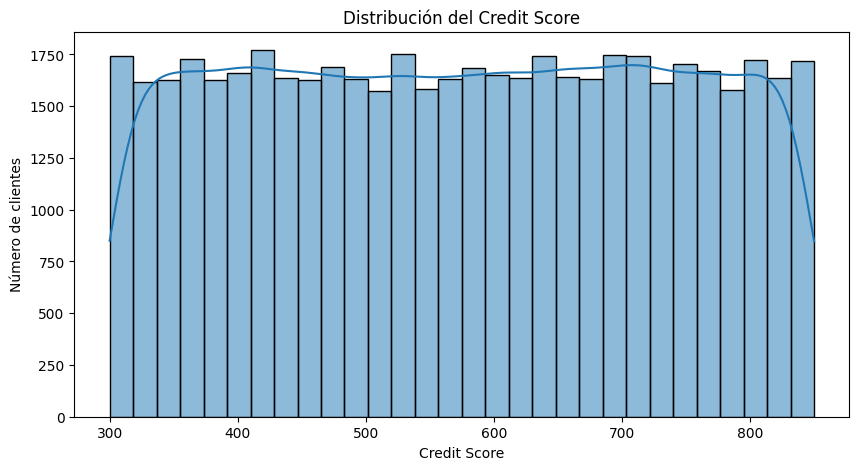

In [18]:
# =============================================================================
# CREDIT SCORE - DISTRIBUCIÓN
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=customer_analysis_df,
    x="credit_score",
    bins=30,
    kde=True,
    ax=ax
)

ax.set_title("Distribución del Credit Score")
ax.set_xlabel("Credit Score")
ax.set_ylabel("Número de clientes")

plt.show()

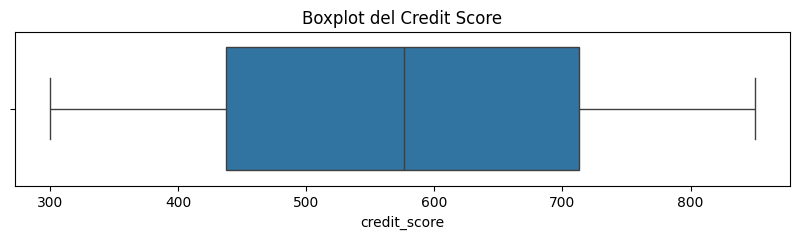

In [19]:
# =============================================================================
# CREDIT SCORE - BOXPLOT
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 2))

sns.boxplot(
    data=customer_analysis_df,
    x="credit_score",
    ax=ax
)

ax.set_title("Boxplot del Credit Score")

plt.show()

### Análisis e interpretación

El histograma muestra una distribución prácticamente uniforme del credit score entre 300 y 850 puntos, sin concentraciones claras en ningún intervalo específico.

El boxplot confirma esta distribución, mostrando una mediana centrada y ausencia de valores atípicos, lo que indica que todas las observaciones se encuentran dentro del rango esperado.

En conjunto, el credit score presenta una distribución homogénea y una amplia variabilidad, proporcionando una representación equilibrada de clientes con diferentes niveles de solvencia.

### Business Insight

La cartera de clientes incluye perfiles con todo el espectro de solvencia crediticia, desde puntuaciones bajas hasta puntuaciones excelentes. Esto permitirá analizar posteriormente si el comportamiento financiero agregado varía en función del nivel de riesgo crediticio.

### 5.2 Total Accounts

La variable **total_accounts** representa el número total de cuentas asociadas a cada cliente. Su análisis permite comprender cómo se distribuyen los productos bancarios entre la cartera de clientes.

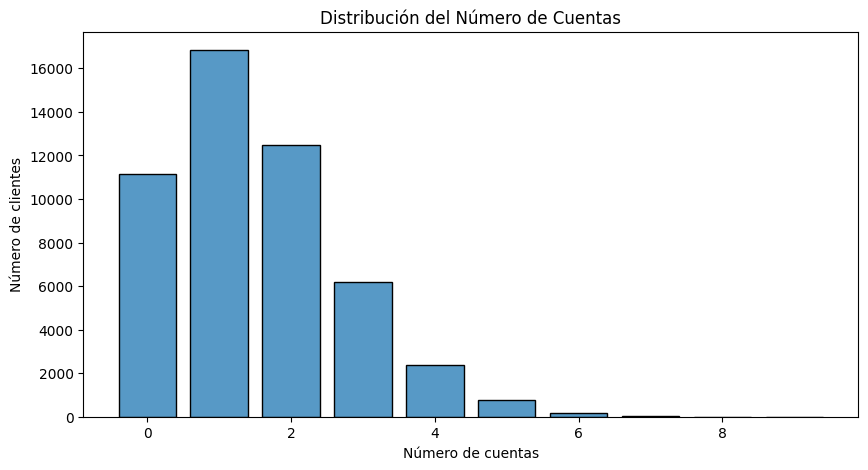

In [20]:
# =============================================================================
# TOTAL ACCOUNTS - DISTRIBUCIÓN
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=customer_analysis_df,
    x="total_accounts",
    discrete=True,
    shrink=0.8,
    ax=ax
)

ax.set_title("Distribución del Número de Cuentas")
ax.set_xlabel("Número de cuentas")
ax.set_ylabel("Número de clientes")

plt.show()

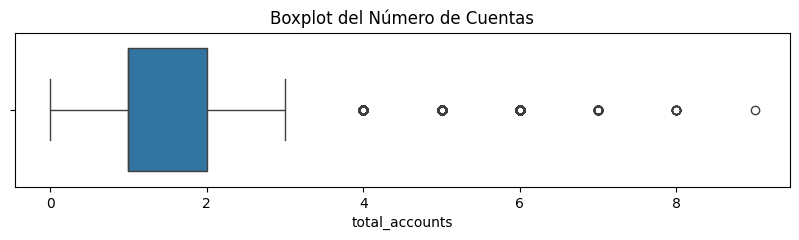

In [21]:
# =============================================================================
# TOTAL ACCOUNTS - BOXPLOT
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 2))

sns.boxplot(
    data=customer_analysis_df,
    x="total_accounts",
    ax=ax
)

ax.set_title("Boxplot del Número de Cuentas")

plt.show()

### Análisis e interpretación

La distribución del número de cuentas presenta una clara asimetría positiva. La mayor parte de los clientes posee entre una y dos cuentas bancarias, mientras que el número de clientes disminuye progresivamente a medida que aumenta el número de cuentas.

El boxplot confirma este comportamiento, mostrando que la mayoría de las observaciones se concentran en valores bajos y que existen clientes con cuatro o más cuentas, identificados como valores atípicos desde un punto de vista estadístico.

Estos casos representan un grupo reducido de clientes con un mayor número de cuentas respecto al comportamiento general observado en la cartera.

### Business Insight

La cartera está compuesta principalmente por clientes con un número reducido de cuentas, mientras que existe un grupo minoritario con una mayor contratación de productos bancarios. Este segmento podría representar clientes de mayor vinculación comercial y merece un análisis específico en las siguientes fases del proyecto.

### 5.3 Total Balance

La variable **total_balance** representa el saldo total acumulado por cada cliente considerando todas sus cuentas bancarias. Su análisis permite conocer cómo se distribuye el patrimonio depositado en la entidad e identificar posibles diferencias entre clientes.

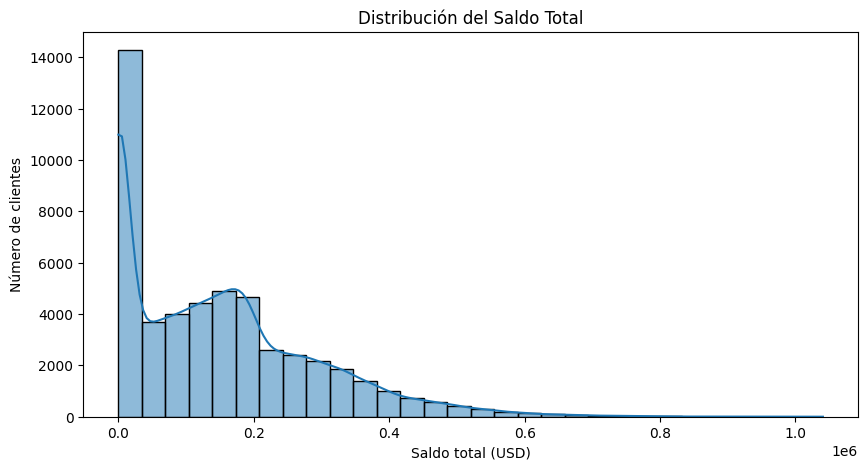

In [22]:
# =============================================================================
# TOTAL BALANCE - DISTRIBUCIÓN
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=customer_analysis_df,
    x="total_balance",
    bins=30,
    kde=True,
    ax=ax
)

ax.set_title("Distribución del Saldo Total")
ax.set_xlabel("Saldo total (USD)")
ax.set_ylabel("Número de clientes")

plt.show()

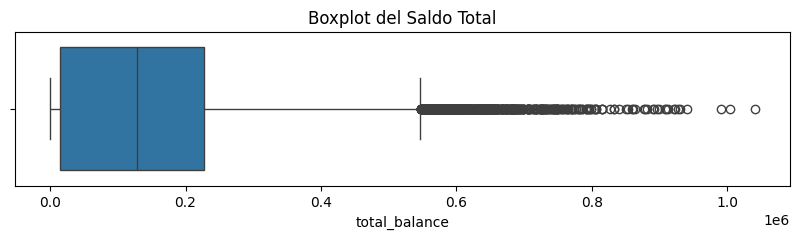

In [23]:
# =============================================================================
# TOTAL BALANCE - BOXPLOT
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 2))

sns.boxplot(
    data=customer_analysis_df,
    x="total_balance",
    ax=ax
)

ax.set_title("Boxplot del Saldo Total")

plt.show()

### Análisis e interpretación

La distribución del saldo total presenta una marcada asimetría positiva. La mayoría de los clientes concentra saldos relativamente bajos o medios, mientras que un grupo reducido acumula saldos significativamente superiores.

El histograma muestra una elevada concentración de clientes en los primeros intervalos de saldo y una disminución progresiva de la frecuencia conforme aumenta el patrimonio depositado.

El boxplot refleja una distribución fuertemente asimétrica hacia valores elevados, mostrando numerosos valores por encima del límite superior definido por el criterio del rango intercuartílico (IQR). Estos valores corresponden a clientes con saldos considerablemente superiores al comportamiento central de la distribución.

### Business Insight

La distribución del saldo evidencia que la cartera está formada principalmente por clientes con niveles de patrimonio bajos o medios, coexistiendo con un grupo reducido de clientes de alto valor económico.

Esta concentración sugiere la existencia de segmentos con necesidades financieras diferentes, lo que podría justificar estrategias comerciales y de fidelización adaptadas al nivel de patrimonio de cada cliente.

### 5.4 Total Cards

La variable **total_cards** representa el número total de tarjetas asociadas a cada cliente. Su análisis permite conocer el grado de adopción de este producto financiero dentro de la cartera de clientes.

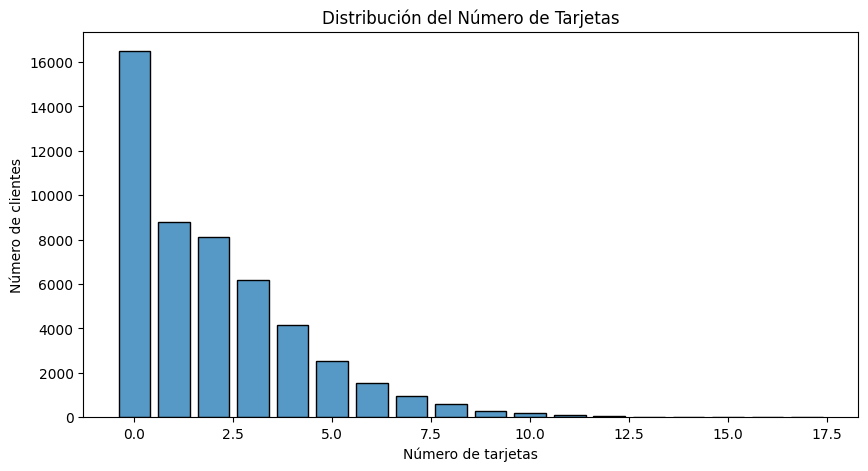

In [24]:
# =============================================================================
# TOTAL CARDS - DISTRIBUCIÓN
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=customer_analysis_df,
    x="total_cards",
    discrete=True,
    shrink=0.8,
    ax=ax
)

ax.set_title("Distribución del Número de Tarjetas")
ax.set_xlabel("Número de tarjetas")
ax.set_ylabel("Número de clientes")

plt.show()

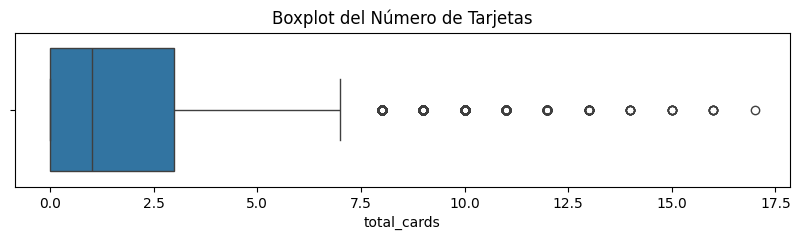

In [25]:
# =============================================================================
# TOTAL CARDS - BOXPLOT
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 2))

sns.boxplot(
    data=customer_analysis_df,
    x="total_cards",
    ax=ax
)

ax.set_title("Boxplot del Número de Tarjetas")

plt.show()

### Análisis e interpretación

La distribución del número de tarjetas presenta una marcada asimetría positiva. La mayor parte de los clientes dispone de pocas tarjetas, siendo especialmente frecuente la ausencia de tarjetas o la posesión de una o dos.

A medida que aumenta el número de tarjetas, la frecuencia de clientes disminuye progresivamente, formando una cola larga hacia la derecha.

El boxplot confirma este comportamiento, identificando clientes con un número elevado de tarjetas por encima del límite superior definido por el criterio del rango intercuartílico (IQR). Estos casos representan un grupo reducido de clientes con una mayor contratación de este producto financiero respecto al comportamiento general de la cartera.

### Business Insight

La mayoría de los clientes mantiene una relación limitada con este producto financiero, mientras que un grupo reducido concentra un número significativamente mayor de tarjetas.

Esta diferencia podría reflejar distintos niveles de vinculación comercial y sugiere la conveniencia de analizar posteriormente si los clientes con más tarjetas presentan también un mayor uso de otros productos y servicios financieros.

### 5.5 Total Loans

La variable **total_loans** representa el número total de préstamos contratados por cada cliente. Su análisis permite conocer el grado de utilización de los productos de financiación dentro de la cartera.

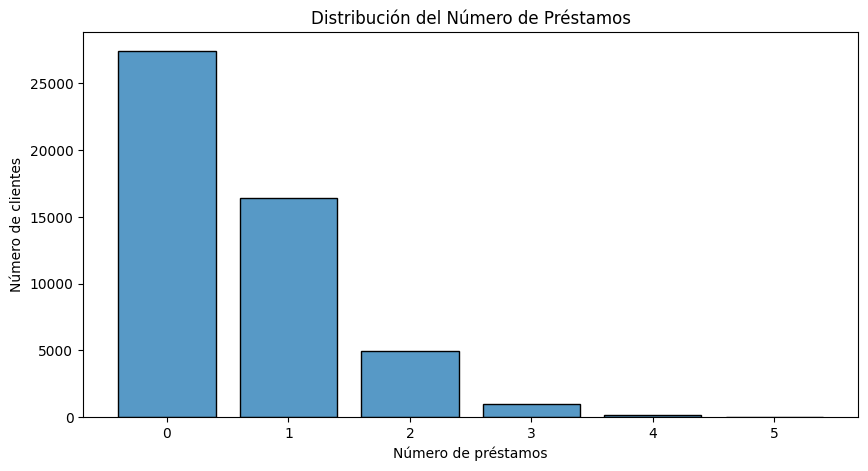

In [26]:
# =============================================================================
# TOTAL LOANS - DISTRIBUCIÓN
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=customer_analysis_df,
    x="total_loans",
    discrete=True,
    shrink=0.8,
    ax=ax
)

ax.set_title("Distribución del Número de Préstamos")
ax.set_xlabel("Número de préstamos")
ax.set_ylabel("Número de clientes")

plt.show()

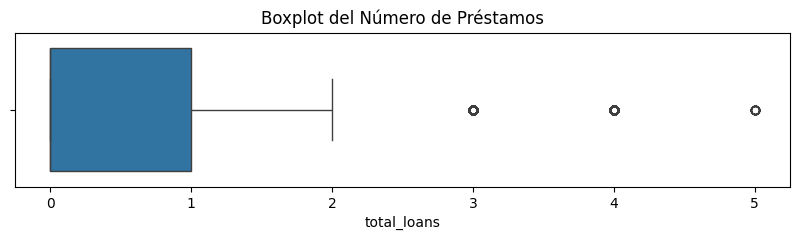

In [27]:
# =============================================================================
# TOTAL LOANS - BOXPLOT
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 2))

sns.boxplot(
    data=customer_analysis_df,
    x="total_loans",
    ax=ax
)

ax.set_title("Boxplot del Número de Préstamos")

plt.show()

### Análisis e interpretación

La distribución del número de préstamos presenta una marcada asimetría positiva. La mayoría de los clientes no dispone de préstamos o mantiene únicamente uno, mientras que el número de clientes disminuye considerablemente a medida que aumenta el número de préstamos contratados.

El histograma muestra una elevada concentración de clientes con cero préstamos, seguida de una reducción progresiva de la frecuencia para valores superiores.

El boxplot refleja este comportamiento, identificando como valores atípicos aquellos clientes con tres o más préstamos según el criterio del rango intercuartílico (IQR). Estos casos representan un grupo reducido de clientes con un nivel de financiación superior al observado en la mayor parte de la cartera.

### Business Insight

La baja utilización de productos de financiación sugiere que el crédito se concentra en un segmento específico de clientes. Identificar las características de este grupo puede ayudar a diseñar campañas comerciales más focalizadas y mejorar las estrategias de concesión de préstamos.

### 5.6 Total Loan Amount

La variable **total_loan_amount** representa el importe total de los préstamos contratados por cada cliente. Su análisis permite conocer cómo se distribuye el volumen de financiación dentro de la cartera.

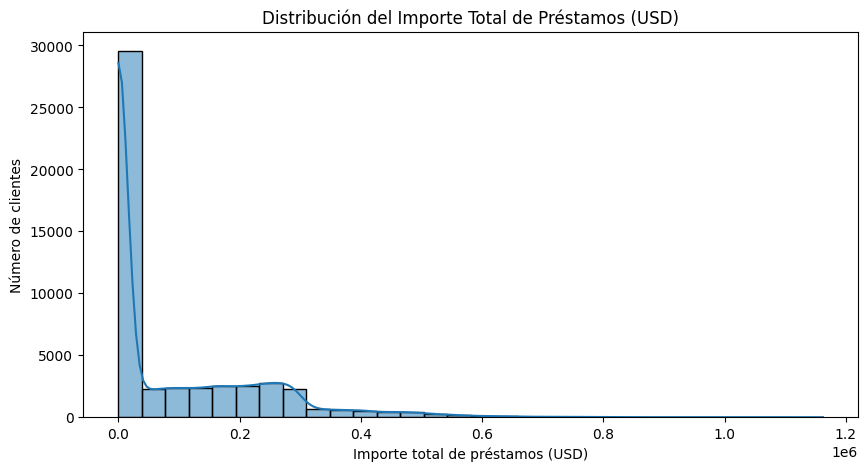

In [28]:
# =============================================================================
# TOTAL LOAN AMOUNT - DISTRIBUCIÓN
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=customer_analysis_df,
    x="total_loan_amount",
    bins=30,
    kde=True,
    ax=ax
)

ax.set_title("Distribución del Importe Total de Préstamos (USD)")
ax.set_xlabel("Importe total de préstamos (USD)")
ax.set_ylabel("Número de clientes")

plt.show()

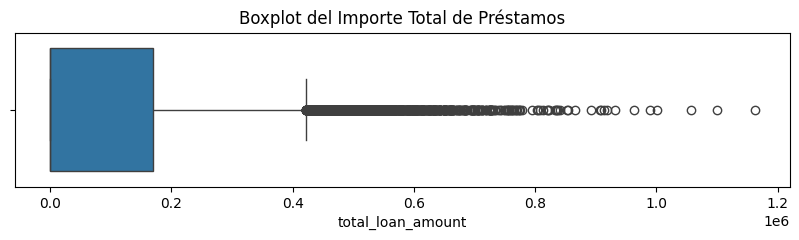

In [29]:
# =============================================================================
# TOTAL LOAN AMOUNT - BOXPLOT
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 2))

sns.boxplot(
    data=customer_analysis_df,
    x="total_loan_amount",
    ax=ax
)

ax.set_title("Boxplot del Importe Total de Préstamos")

plt.show()

### Análisis e interpretación

La distribución del importe total de los préstamos presenta una marcada asimetría positiva. Una parte importante de los clientes no tiene préstamos, lo que genera una elevada concentración de observaciones en valores próximos a cero.

Entre los clientes que sí disponen de financiación, el importe de los préstamos se distribuye en un amplio rango de valores, mientras que la frecuencia disminuye progresivamente conforme aumenta el volumen financiado.

El boxplot refleja esta elevada dispersión, mostrando numerosos valores por encima del límite superior definido por el criterio del rango intercuartílico (IQR). Estos corresponden a clientes con importes de financiación considerablemente superiores al comportamiento central de la distribución.

### Business Insight

El volumen de financiación se concentra en un grupo reducido de clientes, mientras que una parte importante de la cartera no mantiene préstamos activos.

Esta distribución sugiere la coexistencia de perfiles financieros claramente diferenciados, lo que podría justificar estrategias comerciales específicas para clientes con mayor nivel de financiación y para aquellos que aún no utilizan productos de crédito.

### 5.7 Total Transactions

La variable **total_transactions** representa el número total de transacciones realizadas por cada cliente. Su análisis permite conocer el nivel de actividad bancaria dentro de la cartera y detectar diferencias en el uso de los servicios financieros.

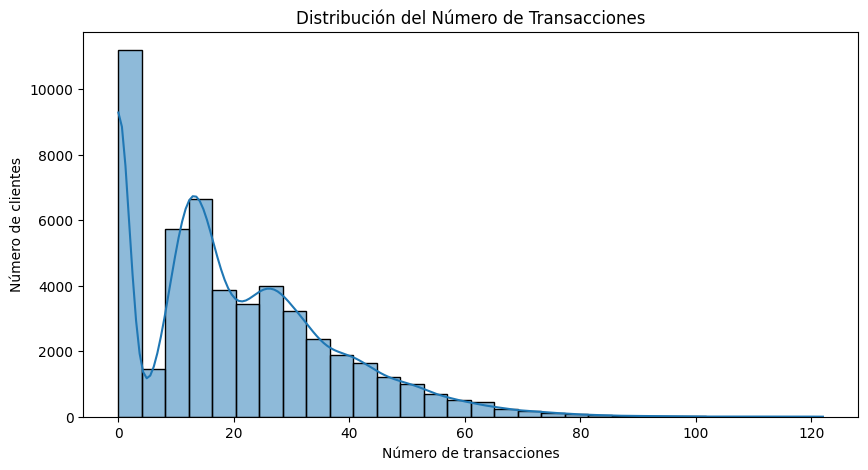

In [30]:
# =============================================================================
# TOTAL TRANSACTIONS - DISTRIBUCIÓN
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=customer_analysis_df,
    x="total_transactions",
    bins=30,
    kde=True,
    ax=ax
)

ax.set_title("Distribución del Número de Transacciones")
ax.set_xlabel("Número de transacciones")
ax.set_ylabel("Número de clientes")

plt.show()

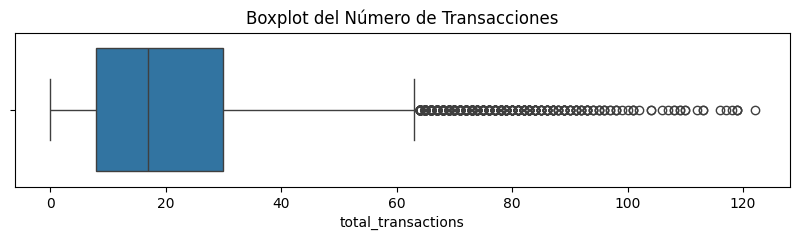

In [31]:
# =============================================================================
# TOTAL TRANSACTIONS - BOXPLOT
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 2))

sns.boxplot(
    data=customer_analysis_df,
    x="total_transactions",
    ax=ax
)

ax.set_title("Boxplot del Número de Transacciones")

plt.show()

### Análisis e interpretación

La distribución presenta una elevada concentración de clientes sin transacciones, seguida de un segundo grupo con un nivel bajo o moderado de actividad bancaria.

El histograma muestra una elevada concentración de clientes con pocas transacciones y una larga cola hacia la derecha, lo que indica la existencia de un grupo reducido de clientes con una actividad significativamente superior al resto de la cartera.

El boxplot confirma este comportamiento, identificando numerosas observaciones por encima del límite superior definido por el criterio del rango intercuartílico (IQR). Estos valores corresponden a clientes con un nivel de actividad bancaria considerablemente superior al comportamiento central de la distribución.

### Business Insight

La actividad transaccional no se distribuye de forma homogénea entre los clientes. Un grupo reducido concentra un volumen significativamente mayor de operaciones, lo que podría indicar un mayor nivel de utilización de los servicios financieros de la entidad.

Identificar este segmento puede resultar útil para diseñar estrategias de fidelización, personalización de servicios o programas dirigidos a clientes con una elevada actividad bancaria.

### 5.8 Total Transaction Amount

La variable **total_transaction_amount** representa el importe total de las transacciones realizadas por cada cliente. Su análisis permite comprender cómo se distribuye el volumen económico de la actividad bancaria dentro de la cartera.

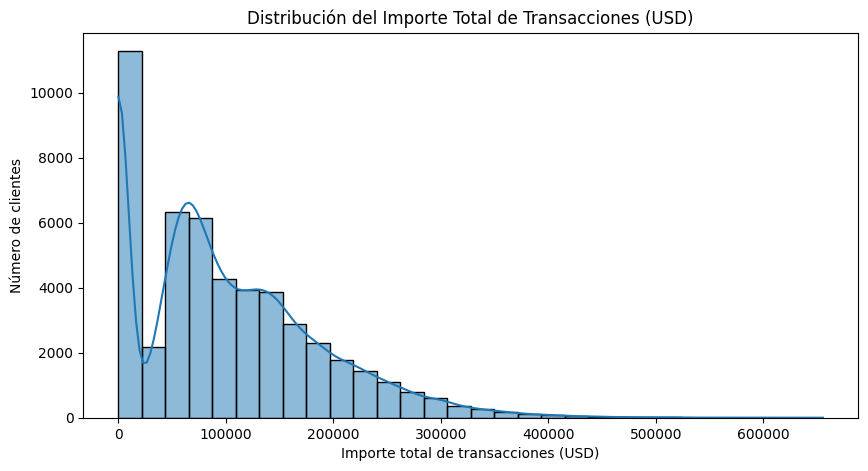

In [32]:
# =============================================================================
# TOTAL TRANSACTION AMOUNT - DISTRIBUCIÓN
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=customer_analysis_df,
    x="total_transaction_amount",
    bins=30,
    kde=True,
    ax=ax
)

ax.set_title("Distribución del Importe Total de Transacciones (USD)")
ax.set_xlabel("Importe total de transacciones (USD)")
ax.set_ylabel("Número de clientes")

plt.show()

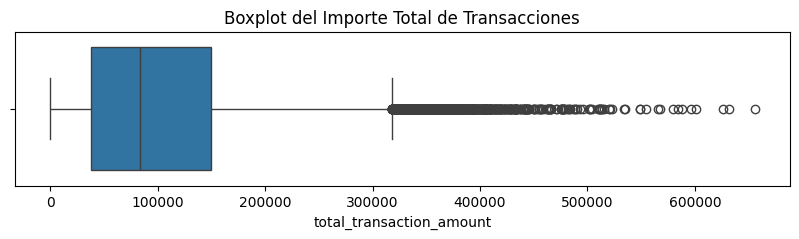

In [33]:
# =============================================================================
# TOTAL TRANSACTION AMOUNT - BOXPLOT
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 2))

sns.boxplot(
    data=customer_analysis_df,
    x="total_transaction_amount",
    ax=ax
)

ax.set_title("Boxplot del Importe Total de Transacciones")

plt.show()

### Análisis e interpretación

La distribución del importe total de las transacciones presenta una marcada asimetría positiva. La mayor parte de los clientes concentra un volumen económico bajo o moderado, mientras que un grupo reducido acumula importes significativamente superiores.

El histograma muestra una elevada concentración de observaciones en los primeros intervalos de importe, seguida de una disminución progresiva de la frecuencia conforme aumenta el volumen total transaccionado.

El boxplot confirma este comportamiento, identificando numerosas observaciones por encima del límite superior definido por el criterio del rango intercuartílico (IQR). Estos casos corresponden a clientes con una actividad económica considerablemente superior al comportamiento central de la cartera.

### Business Insight

La actividad económica de los clientes no se distribuye de forma homogénea. Un grupo reducido concentra un volumen significativamente mayor de transacciones, lo que podría corresponder a clientes con una mayor vinculación o utilización de los servicios financieros.

Identificar este segmento puede contribuir al diseño de estrategias comerciales diferenciadas y a una mejor segmentación de la cartera de clientes.

## 6. Análisis bivariante

### 6.1 Matriz de correlación

La matriz de correlación permite identificar relaciones lineales entre las variables numéricas del dataset analítico. Este análisis proporciona una visión global de la intensidad y dirección de dichas relaciones, facilitando la selección de aquellas que merecen un análisis más detallado.

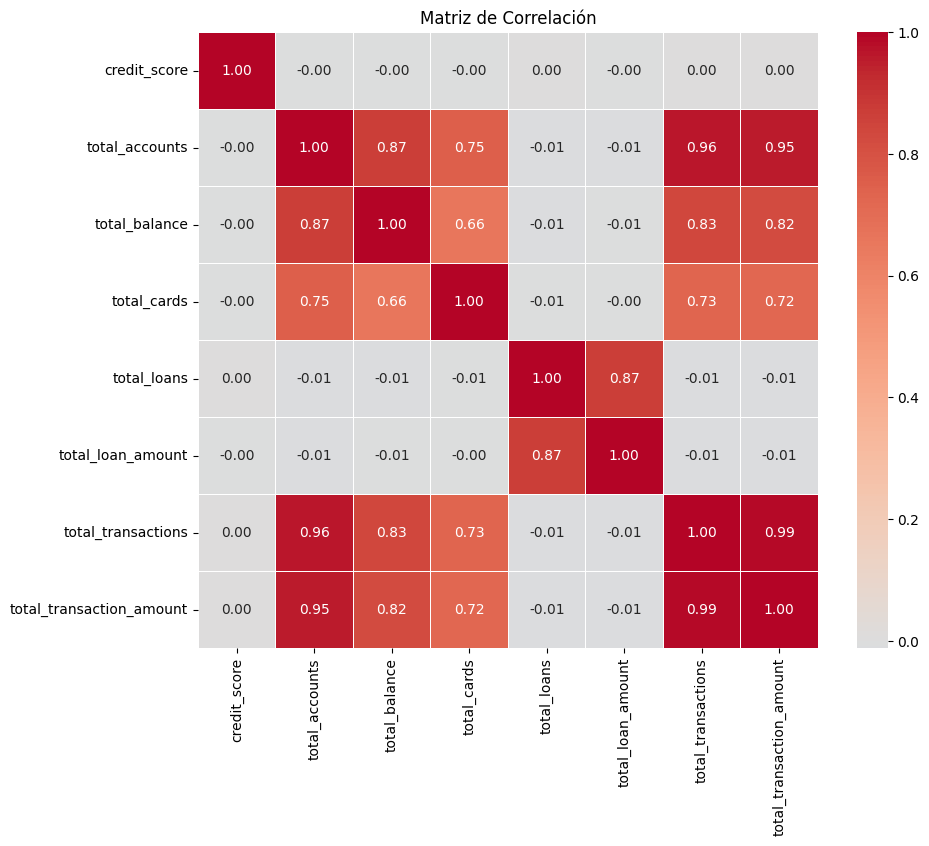

In [34]:
# =============================================================================
# MATRIZ DE CORRELACIÓN
# =============================================================================

correlation_matrix = customer_analysis_df.drop(
    columns="customer_id"
).corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    ax=ax
)

ax.set_title("Matriz de Correlación")

plt.show()

### Análisis e interpretación

La matriz de correlación muestra la existencia de dos grupos principales de variables con una fuerte relación lineal positiva.

Por un lado, las variables relacionadas con la actividad bancaria (`total_accounts`, `total_transactions` y `total_transaction_amount`) presentan correlaciones muy elevadas entre sí. Destaca especialmente la relación entre el número de transacciones y el importe total transaccionado (0.99), indicando que ambas variables evolucionan prácticamente de forma conjunta.

Asimismo, el saldo total (`total_balance`) mantiene una correlación positiva alta con el número de cuentas (0.87), el número de transacciones (0.83) y el importe total de las transacciones (0.82), lo que sugiere que los clientes con mayor patrimonio también tienden a presentar una mayor actividad financiera.

En el ámbito de la financiación, el número de préstamos y el importe total financiado muestran una correlación elevada (0.87), reflejando una relación coherente entre ambas variables.

Por el contrario, el `credit_score` no presenta correlaciones lineales relevantes con el resto de variables del dataset, lo que indica que la solvencia crediticia parece comportarse de forma independiente respecto al nivel de actividad y utilización de productos financieros observado en esta muestra.

### Business Insight

El análisis identifica dos patrones claramente diferenciados dentro de la cartera.

Por una parte, la utilización de productos bancarios y la actividad transaccional evolucionan de forma conjunta, lo que sugiere que los clientes con una mayor vinculación con la entidad también realizan un uso más intensivo de sus servicios.

Por otra parte, la ausencia de una relación lineal entre el credit score y el resto de variables indica que la solvencia crediticia, en este conjunto de datos, no depende directamente del volumen de productos contratados ni de la intensidad de uso de los servicios financieros.

### 6.2 Relación entre el saldo total y el importe total de las transacciones

El objetivo de este análisis es estudiar si existe una relación entre el patrimonio depositado por los clientes y el volumen económico de las transacciones realizadas.

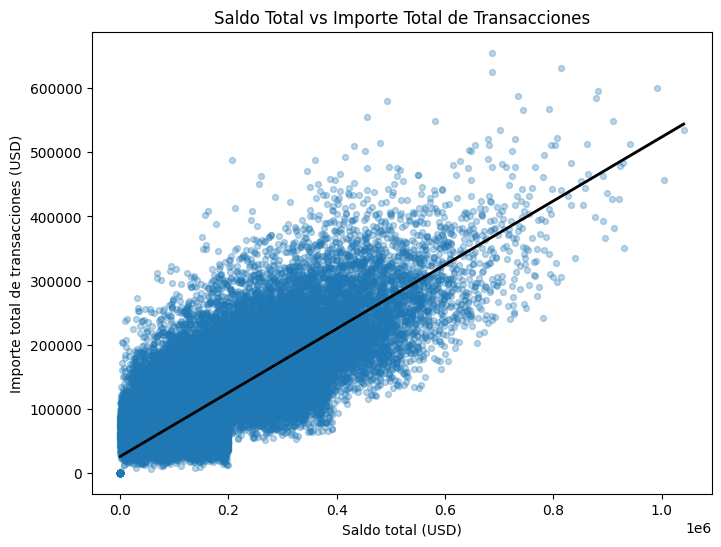

In [35]:
# =============================================================================
# TOTAL BALANCE VS TOTAL TRANSACTION AMOUNT
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=customer_analysis_df,
    x="total_balance",
    y="total_transaction_amount",
    scatter_kws={
        "alpha": 0.30,
        "s": 18
    },
    line_kws={
        "color": "black",
        "linewidth": 2
    },
    ax=ax
)

ax.set_title("Saldo Total vs Importe Total de Transacciones")
ax.set_xlabel("Saldo total (USD)")
ax.set_ylabel("Importe total de transacciones (USD)")

plt.show()

### Análisis e interpretación

El diagrama de dispersión muestra una relación lineal positiva entre el saldo total y el importe total de las transacciones. En general, los clientes con mayores saldos tienden a registrar un mayor volumen económico de transacciones.

La línea de regresión confirma esta tendencia ascendente y resulta coherente con la elevada correlación observada previamente (0.82). Aunque existe dispersión, especialmente para saldos intermedios y elevados, la relación entre ambas variables es claramente positiva.

Asimismo, se observa que la variabilidad del importe total de las transacciones aumenta conforme crece el saldo de los clientes, lo que indica que aquellos con mayor patrimonio presentan comportamientos financieros más heterogéneos.

### Business Insight

Los clientes con mayor saldo mantienen, en términos generales, una actividad económica más elevada dentro de la entidad. Esta relación sugiere que el patrimonio depositado puede utilizarse como un indicador para identificar clientes con mayor nivel de utilización de los servicios financieros.

Este comportamiento puede ser útil para definir estrategias de segmentación y diseñar ofertas comerciales adaptadas a clientes con distintos niveles de patrimonio y actividad.

### 6.3 Relación entre el número de cuentas y el número de tarjetas

El objetivo de este análisis es evaluar si existe una relación entre el número de cuentas contratadas por un cliente y el número de tarjetas asociadas.

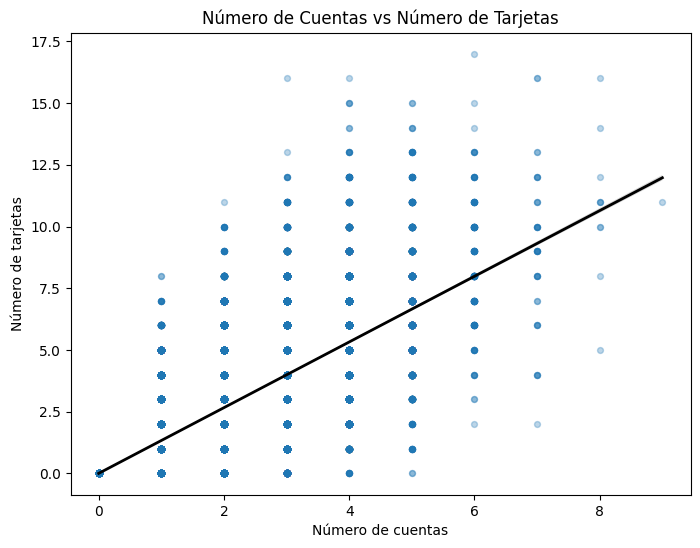

In [36]:
# =============================================================================
# TOTAL ACCOUNTS VS TOTAL CARDS
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=customer_analysis_df,
    x="total_accounts",
    y="total_cards",
    scatter_kws={
        "alpha": 0.30,
        "s": 18
    },
    line_kws={
        "color": "black",
        "linewidth": 2
    },
    ax=ax
)

ax.set_title("Número de Cuentas vs Número de Tarjetas")
ax.set_xlabel("Número de cuentas")
ax.set_ylabel("Número de tarjetas")

plt.show()

### Análisis e interpretación

El diagrama de dispersión muestra una relación lineal positiva entre el número de cuentas y el número de tarjetas. En términos generales, los clientes con un mayor número de cuentas tienden a disponer también de un mayor número de tarjetas.

La línea de regresión confirma esta tendencia ascendente, aunque la dispersión de los datos indica que el número de tarjetas no depende exclusivamente del número de cuentas. Para un mismo número de cuentas se observa una amplia variabilidad en el número de tarjetas contratadas.

Este comportamiento es coherente con la correlación positiva obtenida en la matriz de correlación (0.75), reflejando una asociación moderadamente fuerte entre ambas variables.

### Business Insight

Los clientes con una mayor vinculación a través de cuentas bancarias tienden a contratar también un mayor número de tarjetas. Sin embargo, la elevada dispersión observada sugiere que intervienen otros factores en la contratación de este producto.

Este resultado puede ayudar a identificar oportunidades de venta cruzada, especialmente entre clientes con varias cuentas pero un número reducido de tarjetas.

### 6.4 Relación entre el número de préstamos y el importe total financiado

El objetivo de este análisis es evaluar si los clientes con un mayor número de préstamos concentran también un mayor volumen de financiación.

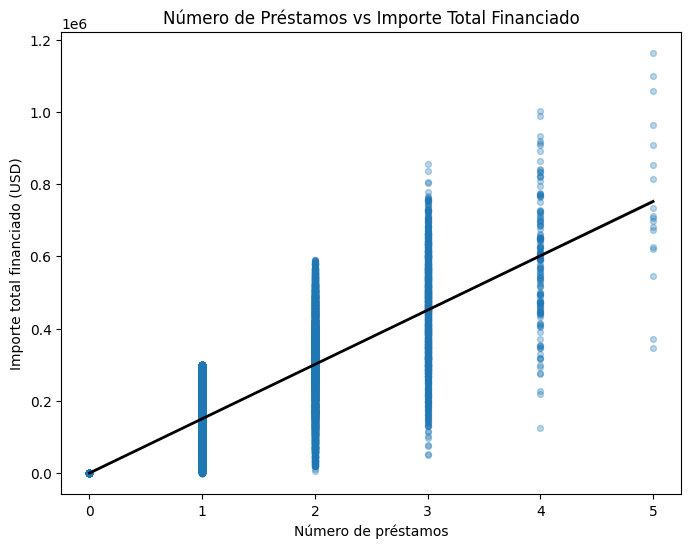

In [37]:
# =============================================================================
# TOTAL LOANS VS TOTAL LOAN AMOUNT
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=customer_analysis_df,
    x="total_loans",
    y="total_loan_amount",
    scatter_kws={
        "alpha": 0.30,
        "s": 18
    },
    line_kws={
        "color": "black",
        "linewidth": 2
    },
    ax=ax
)

ax.set_title("Número de Préstamos vs Importe Total Financiado")
ax.set_xlabel("Número de préstamos")
ax.set_ylabel("Importe total financiado (USD)")

plt.show()

### Análisis e interpretación

El diagrama de dispersión muestra una relación lineal positiva entre el número de préstamos y el importe total financiado. En términos generales, los clientes con un mayor número de préstamos tienden a acumular un volumen superior de financiación.

La línea de regresión confirma esta tendencia ascendente, coherente con la elevada correlación observada previamente (0.87). No obstante, para un mismo número de préstamos se aprecia una variabilidad considerable en el importe financiado, lo que indica que el valor económico de cada préstamo puede diferir significativamente entre clientes.

Este comportamiento sugiere que el importe total financiado depende tanto del número de préstamos como de la cuantía individual de cada uno de ellos.

### Business Insight

Los clientes con un mayor número de préstamos suelen concentrar un mayor volumen de financiación, aunque el importe concedido varía de forma notable entre clientes con un mismo número de préstamos.

Este resultado pone de manifiesto la importancia de analizar conjuntamente la cantidad y el importe de los préstamos para comprender el nivel de exposición crediticia y diseñar estrategias de gestión del riesgo o de comercialización adaptadas a cada perfil.

## 7. Conclusiones

## Principales hallazgos

El análisis exploratorio ha permitido caracterizar el comportamiento financiero de los clientes a partir de variables relacionadas con la actividad bancaria, la contratación de productos y el volumen de financiación.

La mayoría de las variables presentan distribuciones asimétricas positivas, indicando que un grupo reducido de clientes concentra una parte significativa del patrimonio, la actividad transaccional y la financiación.

Asimismo, se identificaron relaciones lineales positivas entre el saldo total y el importe de las transacciones, entre el número de cuentas y el número de tarjetas, y entre el número de préstamos y el importe total financiado.

Por el contrario, el credit score no mostró una relación lineal significativa con el resto de variables analizadas.

---

## Implicaciones para el negocio

Los resultados evidencian la existencia de distintos perfiles de clientes en función de su nivel de actividad y utilización de los productos financieros.

Estos patrones pueden servir como base para iniciativas de segmentación, personalización de ofertas comerciales y apoyo a la toma de decisiones dentro de la entidad financiera.

---

## Conclusión

El dataset analítico construido y validado en este notebook proporciona una visión integrada del comportamiento financiero de los clientes y constituye una base sólida para las siguientes fases del proyecto, incluyendo el desarrollo de modelos predictivos y la creación de dashboards orientados al negocio.